# Project Scenario
Pixel Banking Group wants to better understand loan repayment risk. The task is to use a machine learning workflow to explore the dataset and build a simple model that predicts whether a customer is likely to repay a loan.

# Business Question
> ### *If Pixel Banking Group gives a customer a loan, is that customer likely to repay it?*

In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
file_path = os.path.join('data', 'pixels_banking_loan_repayment_capstone_dataset.csv')
dataframe = pd.read_csv(file_path)

# Explore the data

In [ ]:
data_dict = pd.DataFrame({
    "column": dataframe.columns,
    "data_type": dataframe.dtypes.values,
    "missing_values": dataframe.isnull().sum().values,
    "unique_values": dataframe.nunique().values,
    "example_value": [dataframe[col].dropna().iloc[0] for col in dataframe.columns]
})

data_dict

,column,data_type,missing_values,unique_values,example_value
0,customer_id,object,0,1200,PBG-200312
1,age,float64,24,58,36.0
2,region,object,13,11,London
3,account_type,object,28,4,Premium
4,tenure_months,int64,0,110,24
5,monthly_income,float64,36,1026,2281.0
6,avg_monthly_balance,float64,65,1005,1702.0
7,credit_score,float64,41,307,637.0
8,num_products,int64,0,5,3
9,has_credit_card,object,31,2,Yes


In [ ]:
df = dataframe.copy()
df.head()

,customer_id,age,region,account_type,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,has_credit_card,...,missed_payments_6m,support_rating,contract_type,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
0,PBG-200312,36.0,London,Premium,24,2281.0,1702.0,637.0,3,Yes,...,0,5.0,Annual,16.99,49.0,7500,36,0.36,13.57,0
1,PBG-200958,47.0,South East,Premium,13,4747.0,3045.0,655.0,1,Yes,...,0,NaN,Monthly,16.99,74.0,5000,12,0.14,6.73,1
2,PBG-200402,44.0,West Midlands,Premium,41,5605.0,5230.0,583.0,2,Yes,...,0,2.0,No fixed term,16.99,100.0,3000,48,0.32,12.42,1
3,PBG-200626,49.0,West Midlands,Premium,23,5576.0,7223.0,850.0,3,Yes,...,1,4.0,Monthly,16.99,86.0,15000,48,0.03,3.90,1
4,PBG-200272,32.0,North East,Everyday,63,4737.0,4982.0,691.0,1,No,...,3,4.0,No fixed term,0.00,77.0,10000,12,0.45,7.87,0


In [ ]:
df.shape

(1200, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1176 non-null   float64
 2   region                    1187 non-null   object 
 3   account_type              1172 non-null   object 
 4   tenure_months             1200 non-null   int64  
 5   monthly_income            1164 non-null   float64
 6   avg_monthly_balance       1135 non-null   float64
 7   credit_score              1159 non-null   float64
 8   num_products              1200 non-null   int64  
 9   has_credit_card           1169 non-null   object 
 10  has_crypto_wallet         1200 non-null   object 
 11  uses_mobile_app           1175 non-null   object 
 12  customer_service_calls    1200 non-null   int64  
 13  missed_payments_6m        1200 non-null   int64  
 14  support_

In [ ]:
df.describe().round(2)

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
count,1176.00,1200.00,1164.00,1135.00,1159.00,1200.00,1200.00,1200.00,1135.00,1200.00,1129.00,1200.00,1200.00,1157.00,1164.00,1200.00
mean,39.09,40.43,3514.98,2487.74,667.59,2.29,1.62,0.50,3.43,5.94,77.34,6955.83,31.95,0.24,9.06,0.69
std,12.23,22.69,1656.86,1796.91,74.62,1.13,1.29,0.87,1.13,6.55,19.43,5973.86,14.14,0.12,2.88,0.46
min,18.00,3.00,900.00,0.00,390.00,1.00,0.00,0.00,1.00,0.00,14.00,1000.00,12.00,0.03,3.90,0.00
25%,30.00,23.00,2293.25,1216.00,618.00,1.00,1.00,0.00,3.00,0.00,64.00,3000.00,24.00,0.15,6.99,0.00
50%,39.00,36.00,3163.50,2125.00,668.00,2.00,1.00,0.00,4.00,7.00,81.00,5000.00,36.00,0.23,9.03,1.00
75%,47.00,53.00,4350.00,3349.00,717.50,3.00,2.00,1.00,4.00,12.00,94.00,10000.00,36.00,0.32,11.06,1.00
max,78.00,144.00,9960.00,11032.00,850.00,5.00,8.00,4.00,5.00,16.99,100.00,25000.00,60.00,0.61,20.19,1.00


In [ ]:
df.isnull().sum()

,0
customer_id,0
age,24
region,13
account_type,28
tenure_months,0
monthly_income,36
avg_monthly_balance,65
credit_score,41
num_products,0
has_credit_card,31


### Visualise loan repayment

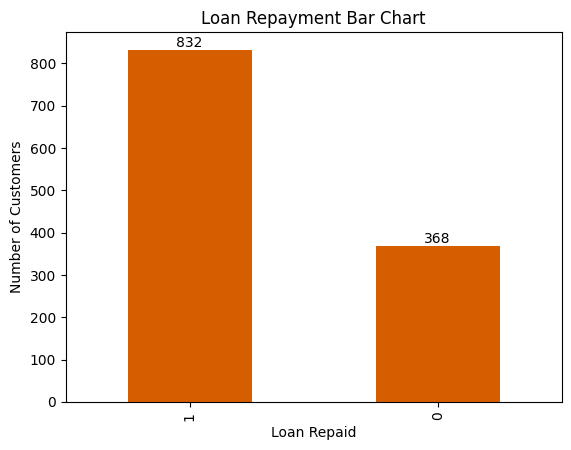

In [ ]:
# 1 = loan repaid
# 0 = loan unpaid

counts = df["loan_repaid"].value_counts()

ax = counts.plot(kind="bar", color="#D55E00")

ax.set_title("Loan Repayment Bar Chart")
ax.set_xlabel("Loan Repaid")
ax.set_ylabel("Number of Customers")

ax.bar_label(ax.containers[0])

plt.show()

### Loan repaid pct for each contract type

In [ ]:
contract_pct = df.groupby("contract_type")["loan_repaid"].mean().round(4) * 100

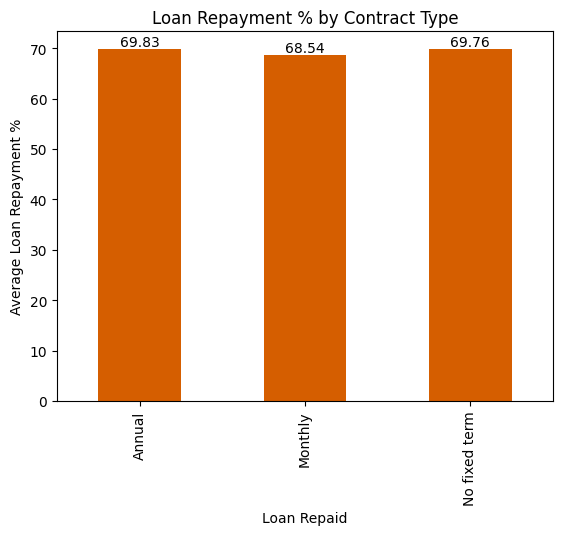

In [ ]:
ax = contract_pct.plot(kind="bar", color="#D55E00")

ax.set_title("Loan Repayment % by Contract Type")
ax.set_xlabel("Loan Repaid")
ax.set_ylabel("Average Loan Repayment %")

ax.bar_label(ax.containers[0])

plt.show()

### Loan repaid pct for each acount type

In [ ]:
account_pct = df.groupby("account_type")["loan_repaid"].mean().round(4) * 100

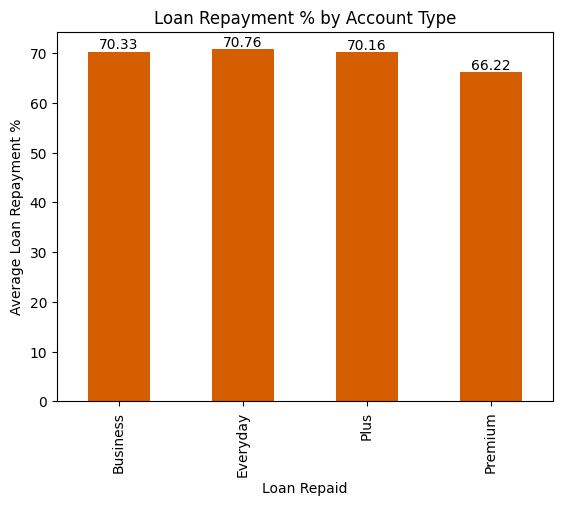

In [ ]:
ax = account_pct.plot(kind="bar", color="#D55E00")

ax.set_title("Loan Repayment % by Account Type")
ax.set_xlabel("Loan Repaid")
ax.set_ylabel("Average Loan Repayment %")

ax.bar_label(ax.containers[0])

plt.show()

### Loan repaid pct for each region

In [ ]:
region_pct = df.groupby("region")["loan_repaid"].mean().round(4) * 100

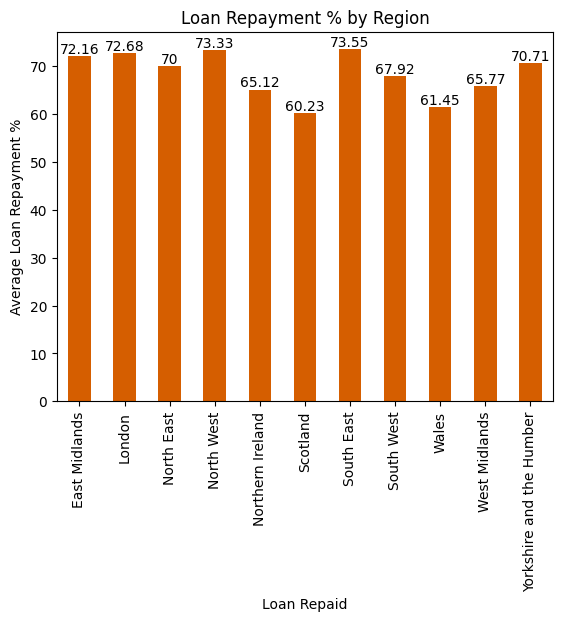

In [ ]:
ax = region_pct.plot(kind="bar", color="#D55E00")

ax.set_title("Loan Repayment % by Region")
ax.set_xlabel("Loan Repaid")
ax.set_ylabel("Average Loan Repayment %")

ax.bar_label(ax.containers[0])

plt.show()

### Correlation between numerical columns

In [ ]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
age,1.000000,0.004554,0.046592,0.041487,0.056837,-0.001258,-0.025022,-0.013205,0.011636,0.025308,0.062130,0.051255,-0.001969,-0.010010,-0.013204,0.015121
tenure_months,0.004554,1.000000,0.019899,0.036587,-0.009169,0.012303,0.055949,0.055060,-0.048675,-0.024166,0.021666,0.018495,-0.033788,0.042095,0.003110,0.040619
monthly_income,0.046592,0.019899,1.000000,0.682567,-0.073595,0.011461,-0.004376,-0.051555,0.053603,0.059324,0.054096,0.004305,-0.037555,-0.013036,0.055764,0.087365
avg_monthly_balance,0.041487,0.036587,0.682567,1.000000,-0.025833,-0.009593,-0.011087,-0.017176,0.024549,0.055349,0.039885,-0.006147,-0.040348,-0.049522,-0.000341,0.047506
credit_score,0.056837,-0.009169,-0.073595,-0.025833,1.000000,0.011728,0.000225,0.003253,-0.001804,0.022057,0.038890,0.037392,0.046090,-0.020987,-0.874725,0.236844
num_products,-0.001258,0.012303,0.011461,-0.009593,0.011728,1.000000,0.039261,-0.001103,-0.044038,-0.009416,0.007726,0.017866,-0.025005,0.018958,-0.004803,0.029363
customer_service_calls,-0.025022,0.055949,-0.004376,-0.011087,0.000225,0.039261,1.000000,0.002146,0.000277,-0.036987,-0.036521,0.008736,-0.003045,0.026740,0.005708,-0.023119
missed_payments_6m,-0.013205,0.055060,-0.051555,-0.017176,0.003253,-0.001103,0.002146,1.000000,-0.044480,0.029275,-0.016243,-0.000396,0.028497,0.245150,0.059547,-0.300195
support_rating,0.011636,-0.048675,0.053603,0.024549,-0.001804,-0.044038,0.000277,-0.044480,1.000000,0.031021,0.068928,-0.037577,0.042722,-0.004984,0.025682,0.025941
monthly_fees,0.025308,-0.024166,0.059324,0.055349,0.022057,-0.009416,-0.036987,0.029275,0.031021,1.000000,0.036431,-0.023227,0.043474,0.023243,-0.013281,-0.025506


### Visualise correlations

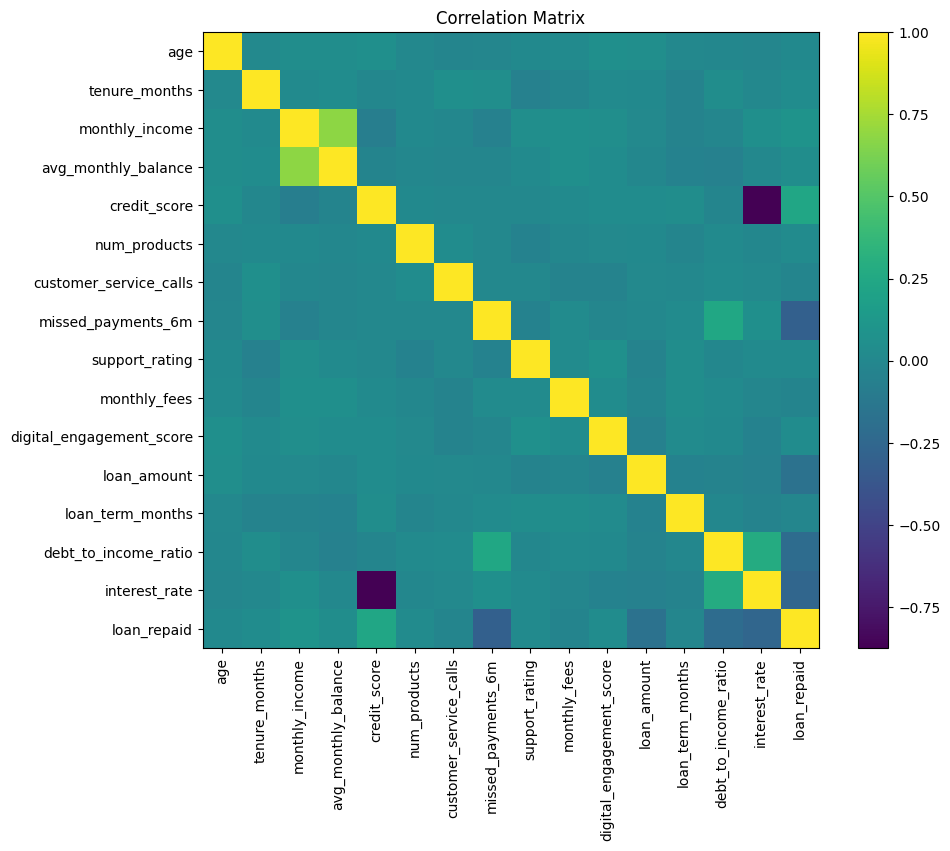

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr())

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Matrix")

plt.show()

## Prepare/ Clean data

### Removing meaningless columms

In [ ]:
customer_ids = df["customer_id"].values # Save customer IDs for later corresponding to the test set
df = df.drop(columns=['customer_id'], errors='ignore')
df.head()

,age,region,account_type,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,has_credit_card,has_crypto_wallet,...,missed_payments_6m,support_rating,contract_type,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
0,36.0,London,Premium,24,2281.0,1702.0,637.0,3,Yes,No,...,0,5.0,Annual,16.99,49.0,7500,36,0.36,13.57,0
1,47.0,South East,Premium,13,4747.0,3045.0,655.0,1,Yes,No,...,0,NaN,Monthly,16.99,74.0,5000,12,0.14,6.73,1
2,44.0,West Midlands,Premium,41,5605.0,5230.0,583.0,2,Yes,No,...,0,2.0,No fixed term,16.99,100.0,3000,48,0.32,12.42,1
3,49.0,West Midlands,Premium,23,5576.0,7223.0,850.0,3,Yes,Yes,...,1,4.0,Monthly,16.99,86.0,15000,48,0.03,3.90,1
4,32.0,North East,Everyday,63,4737.0,4982.0,691.0,1,No,Yes,...,3,4.0,No fixed term,0.00,77.0,10000,12,0.45,7.87,0


In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [ ]:
print('Numeric columns:')
print(list(numeric_columns))

print('Categorical columns:')
print(list(categorical_columns))

Numeric columns:
['age', 'tenure_months', 'monthly_income', 'avg_monthly_balance', 'credit_score', 'num_products', 'customer_service_calls', 'missed_payments_6m', 'support_rating', 'monthly_fees', 'digital_engagement_score', 'loan_amount', 'loan_term_months', 'debt_to_income_ratio', 'interest_rate', 'loan_repaid']
Categorical columns:
['region', 'account_type', 'has_credit_card', 'has_crypto_wallet', 'uses_mobile_app', 'contract_type']


### Handling missing values

In [ ]:
for column in numeric_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

for column in categorical_columns:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)

###  Values in each categorical column

In [ ]:
for column in categorical_columns:
    print(column, "\n")
    print(df[column].value_counts())
    print('--------------------------------')

region 

region
London                      218
South East                  155
North West                  120
West Midlands               111
South West                  106
Yorkshire and the Humber     99
East Midlands                97
Scotland                     88
Wales                        83
North East                   80
Northern Ireland             43
Name: count, dtype: int64
--------------------------------
account_type 

account_type
Everyday    582
Plus        305
Premium     222
Business     91
Name: count, dtype: int64
--------------------------------
has_credit_card 

has_credit_card
Yes    700
No     500
Name: count, dtype: int64
--------------------------------
has_crypto_wallet 

has_crypto_wallet
No     985
Yes    215
Name: count, dtype: int64
--------------------------------
uses_mobile_app 

uses_mobile_app
Yes    924
No     276
Name: count, dtype: int64
--------------------------------
contract_type 

contract_type
Monthly          445
Annual           421
N

### One hot encoding categorical data

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df_encoded.head()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,...,region_West Midlands,region_Yorkshire and the Humber,account_type_Everyday,account_type_Plus,account_type_Premium,has_credit_card_Yes,has_crypto_wallet_Yes,uses_mobile_app_Yes,contract_type_Monthly,contract_type_No fixed term
0,36.0,24,2281.0,1702.0,637.0,3,3,0,5.0,16.99,...,False,False,False,False,True,True,False,False,False,False
1,47.0,13,4747.0,3045.0,655.0,1,2,0,4.0,16.99,...,False,False,False,False,True,True,False,False,True,False
2,44.0,41,5605.0,5230.0,583.0,2,0,0,2.0,16.99,...,True,False,False,False,True,True,False,True,False,True
3,49.0,23,5576.0,7223.0,850.0,3,2,1,4.0,16.99,...,True,False,False,False,True,True,True,True,True,False
4,32.0,63,4737.0,4982.0,691.0,1,1,3,4.0,0.00,...,False,False,True,False,False,False,True,True,False,True


In [ ]:
list(df_encoded.columns)

['age',
 'tenure_months',
 'monthly_income',
 'avg_monthly_balance',
 'credit_score',
 'num_products',
 'customer_service_calls',
 'missed_payments_6m',
 'support_rating',
 'monthly_fees',
 'digital_engagement_score',
 'loan_amount',
 'loan_term_months',
 'debt_to_income_ratio',
 'interest_rate',
 'loan_repaid',
 'region_London',
 'region_North East',
 'region_North West',
 'region_Northern Ireland',
 'region_Scotland',
 'region_South East',
 'region_South West',
 'region_Wales',
 'region_West Midlands',
 'region_Yorkshire and the Humber',
 'account_type_Everyday',
 'account_type_Plus',
 'account_type_Premium',
 'has_credit_card_Yes',
 'has_crypto_wallet_Yes',
 'uses_mobile_app_Yes',
 'contract_type_Monthly',
 'contract_type_No fixed term']

### Final checks

In [ ]:
print('Missing values left:', df_encoded.isnull().sum().sum())
print('Text columns left:', list(df_encoded.select_dtypes(include='object').columns))
print('Final shape:', df_encoded.shape)
print('Customer ID still present:', 'customer_id' in df_encoded.columns)

Missing values left: 0
Text columns left: []
Final shape: (1200, 34)
Customer ID still present: False


In [ ]:
df_model_ready = df_encoded.copy()

# Training and Testing the Machine Learning Model

### Create features and label
Split dataset into features (X) and label/target for prediction (y).

### The label (y) is loan_repaid

In [ ]:
X = df_model_ready.drop(columns=['loan_repaid'])

In [ ]:
y = df_model_ready['loan_repaid']

In [ ]:
X.head()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,...,region_West Midlands,region_Yorkshire and the Humber,account_type_Everyday,account_type_Plus,account_type_Premium,has_credit_card_Yes,has_crypto_wallet_Yes,uses_mobile_app_Yes,contract_type_Monthly,contract_type_No fixed term
0,36.0,24,2281.0,1702.0,637.0,3,3,0,5.0,16.99,...,False,False,False,False,True,True,False,False,False,False
1,47.0,13,4747.0,3045.0,655.0,1,2,0,4.0,16.99,...,False,False,False,False,True,True,False,False,True,False
2,44.0,41,5605.0,5230.0,583.0,2,0,0,2.0,16.99,...,True,False,False,False,True,True,False,True,False,True
3,49.0,23,5576.0,7223.0,850.0,3,2,1,4.0,16.99,...,True,False,False,False,True,True,True,True,True,False
4,32.0,63,4737.0,4982.0,691.0,1,1,3,4.0,0.00,...,False,False,True,False,False,False,True,True,False,True


In [ ]:
y.head()

,loan_repaid
0,0
1,1
2,1
3,1
4,0


### Check balance of label

In [ ]:
y.value_counts()

,count
loan_repaid,
1,832
0,368


In [ ]:
y.value_counts(normalize=True)

,proportion
loan_repaid,
1,0.693333
0,0.306667


### Split data into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training features:', X_train.shape)
print('Testing features:', X_test.shape)
print('Training labels:', y_train.shape)
print('Testing labels:', y_test.shape)

Training features: (960, 33)
Testing features: (240, 33)
Training labels: (960,)
Testing labels: (240,)


### Create the model

In [ ]:
model = LogisticRegression(max_iter=1000, solver="liblinear")

### Train the model

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

### Test the model to make predictions

Give the model the test features, `X_test` to predict if a customer repaid loan

In [ ]:
y_predictions = model.predict(X_test)

### Predict loan repayment probabilities


`predict_proba` table:

column 0 = probability of class 0 (loan unpaid)

column 1 = probability of class 1 (loan repaid)

In [ ]:
y_probability = model.predict_proba(X_test)

results = pd.DataFrame({
    "customer_id": customer_ids[y_test.index],
    "actual": y_test.values,
    "predicted": y_predictions,
    "repaid probability": y_probability[:, 1]
})

### Customers most likely to not repay loan

In [ ]:
results.sort_values(by='repaid probability', ascending=True)

,customer_id,actual,predicted,repaid probability
72,PBG-200340,0,0,0.073378
29,PBG-200858,0,0,0.084473
208,PBG-200319,1,0,0.119405
3,PBG-201055,0,0,0.124179
178,PBG-200668,0,0,0.133586
...,...,...,...,...
8,PBG-200954,1,1,0.965177
124,PBG-200912,1,1,0.969630
220,PBG-200148,1,1,0.969903
195,PBG-200198,1,1,0.980888


### Calculate accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_predictions)

print('Accuracy:', round(accuracy, 3))
print('Accuracy percentage:', round(accuracy * 100, 1), '%')

Accuracy: 0.75
Accuracy percentage: 75.0 %


## Confusion matrix


**True Negative (TN)**

- predicted loan unpaid, actually loan unpaid


**False Positive (FP)**

- predicted loan repaid, actually loan unpaid

**False Negative (FN)**

- predicted loan unpaid, actually loan repaid

**True Positive (TP)**

- predicted loan repaid, actually loan repaid

In [ ]:
cm = confusion_matrix(y_test, y_predictions)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Loan Unpaid', 'Actual Loan Repaid'],
    columns=['Predicted Loan Unpaid', 'Predicted Load Repaid']
)

cm_df

,Predicted Loan Unpaid,Predicted Load Repaid
Actual Loan Unpaid,30,44
Actual Loan Repaid,16,150


### Classification report

In [ ]:
print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.65      0.41      0.50        74
           1       0.77      0.90      0.83       166

    accuracy                           0.75       240
   macro avg       0.71      0.65      0.67       240
weighted avg       0.74      0.75      0.73       240

